# 04. Probabilidade e Distribuições

## 1. Visão geral

A probabilidade é a linguagem matemática usada para representar incerteza. Em ciência de dados, ela aparece em problemas de previsão, classificação, testes estatísticos, simulação e modelagem de fenômenos aleatórios.

Neste capítulo, vamos construir uma base prática para entender:

- o que é probabilidade;
- como interpretar eventos aleatórios;
- como funcionam distribuições discretas e contínuas;
- por que simulações são úteis;
- como a Lei dos Grandes Números ajuda a estabilizar estimativas.

Ao longo do capítulo, vamos combinar **conceito, simulação, visualização e interpretação**, sempre conectando a teoria com exemplos em Python.

## 2. Imports e configuração inicial


In [21]:
# CÉLULA 1 — IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Define uma semente para garantir reprodutibilidade
np.random.seed(42)

## 3. Experimento aleatório, espaço amostral e eventos

### 3.1 Conceitos fundamentais

Antes de falar de distribuições, é importante entender três ideias centrais:

- **Experimento aleatório:** processo cujo resultado não pode ser previsto com certeza antes de acontecer.
- **Espaço amostral:** conjunto de todos os resultados possíveis.
- **Evento:** subconjunto do espaço amostral.

No caso de um dado justo de seis faces:

- experimento: lançar o dado;
- espaço amostral: $\Omega = \{1,2,3,4,5,6\}$;
- evento “tirar número par”: $A = \{2,4,6\}$.

Quando todos os resultados têm a mesma chance de ocorrer, podemos usar a definição clássica de probabilidade:

$$
P(A) = \frac{\text{casos favoráveis}}{\text{casos possíveis}}
$$

## 4. Simulação de um dado

Vamos começar com um exemplo simples: simular vários lançamentos de um dado. Esse tipo de exercício ajuda a visualizar como a probabilidade teórica aparece na prática.


In [22]:
# CÉLULA 2 — SIMULAÇÃO DE LANÇAMENTOS DE UM DADO

# Gera 10.000 lançamentos de um dado justo
# randint(1, 7) gera inteiros entre 1 e 6
resultados_dado = np.random.randint(1, 7, size=10000)

# Visualização inicial
resultados_dado[:10]

array([4, 5, 3, 5, 5, 2, 3, 3, 3, 5])

In [23]:
# CÉLULA 3 — FREQUÊNCIA RELATIVA DAS FACES

frequencias = pd.Series(resultados_dado).value_counts().sort_index()
frequencias_relativas = frequencias / frequencias.sum()

df_freq = pd.DataFrame({
    "face": frequencias.index,
    "frequencia": frequencias.values,
    "frequencia_relativa": frequencias_relativas.values
})

df_freq

,face,frequencia,frequencia_relativa
0,1,1665,0.1665
1,2,1692,0.1692
2,3,1625,0.1625
3,4,1672,0.1672
4,5,1689,0.1689
5,6,1657,0.1657


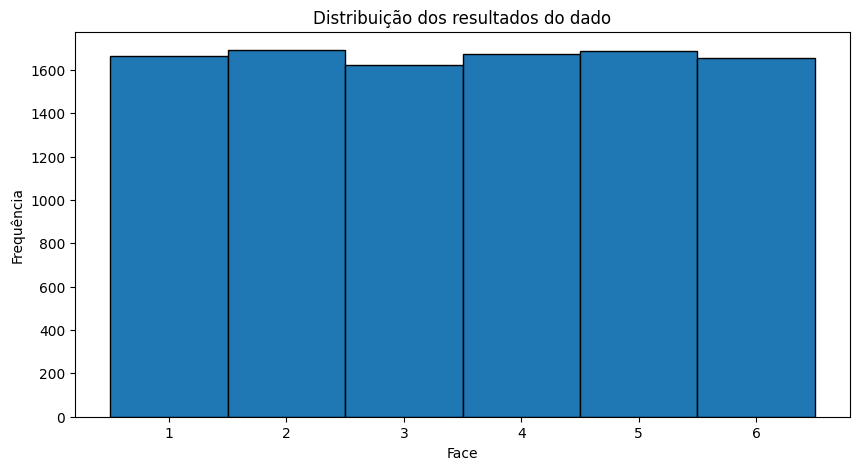

In [24]:
# CÉLULA 4 — HISTOGRAMA DOS RESULTADOS DO DADO

plt.figure(figsize=(10, 5))
plt.hist(resultados_dado, bins=np.arange(0.5, 7.5, 1), edgecolor="black")

plt.title("Distribuição dos resultados do dado")
plt.xlabel("Face")
plt.ylabel("Frequência")
plt.show()

> **Interpretação:**  
> O histograma mostra que as seis faces aparecem com frequências bastante próximas, o que é compatível com o comportamento esperado de um dado justo. Pequenas diferenças entre as barras são naturais e decorrem da variabilidade aleatória da simulação.


## 5. Probabilidade empírica e probabilidade teórica

A **probabilidade teórica** é derivada do modelo matemático. A **probabilidade empírica** é estimada a partir dos dados observados.

No dado justo:

- probabilidade teórica de tirar 6: \(1/6 \approx 0.167\)
- probabilidade empírica: proporção de vezes em que o valor 6 apareceu na simulação


In [25]:
# CÉLULA 5 — PROBABILIDADE EMPÍRICA DE TIRAR 6

prob_empirica_6 = np.mean(resultados_dado == 6)
prob_teorica_6 = 1 / 6

print(f"Probabilidade teórica de tirar 6: {prob_teorica_6:.4f}")
print(f"Probabilidade empírica de tirar 6: {prob_empirica_6:.4f}")

Probabilidade teórica de tirar 6: 0.1667
Probabilidade empírica de tirar 6: 0.1657


## 6. Probabilidade condicional

A probabilidade condicional mede a chance de um evento ocorrer dado que outro já ocorreu.

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

Em termos práticos, ela responde perguntas como:

- qual a chance de um cliente cancelar **dado que** já reclamou?
- qual a chance de fraude **dado que** a compra veio de um dispositivo novo?
- qual a chance de sair um número maior que 4 **dado que o resultado foi par**?


In [26]:
# CÉLULA 6 — EXEMPLO DE PROBABILIDADE CONDICIONAL NO DADO

# Evento A: resultado maior que 4
A = np.isin(resultados_dado, [5, 6])

# Evento B: resultado par
B = np.isin(resultados_dado, [2, 4, 6])

# P(A | B) = P(A e B) / P(B)
p_A_dado_B = np.mean(A & B) / np.mean(B)

print(f"P(resultado > 4 | resultado par) = {p_A_dado_B:.4f}")

P(resultado > 4 | resultado par) = 0.3300


Nesse caso, se sabemos que o resultado foi par, os valores possíveis passam a ser apenas \(\{2,4,6\}\). Dentre eles, apenas o valor 6 é maior que 4. Logo, a probabilidade esperada é \(1/3\).


## 7. Variáveis aleatórias e distribuições

Uma **variável aleatória** associa números aos resultados de um experimento aleatório.

Exemplos:

- número de compras em um dia;
- quantidade de cliques em um anúncio;
- tempo de atendimento;
- número de sucessos em uma sequência de tentativas.

As distribuições de probabilidade descrevem como os valores dessa variável tendem a se comportar.

De forma geral, podemos separar em:

- **discretas:** assumem valores contáveis;
- **contínuas:** assumem valores em intervalos contínuos.


## 8. Distribuição Binomial

A distribuição binomial modela o número de sucessos em um conjunto fixo de tentativas independentes, quando cada tentativa possui apenas dois resultados possíveis: sucesso ou fracasso.

Exemplos:

- número de clientes que clicam em um botão;
- quantidade de aprovações em um lote;
- número de conversões em campanhas de marketing.

Se $X \sim Bin(n, p)$, então:

- $n$: número de tentativas;
- $p$: probabilidade de sucesso em cada tentativa.

In [27]:
# CÉLULA 7 — PARÂMETROS DA DISTRIBUIÇÃO BINOMIAL

# n: número de tentativas
n = 10

# p: probabilidade de sucesso em cada tentativa
p = 0.5

# Possíveis números de sucesso
valores_binom = np.arange(0, n + 1)

# pmf = probability mass function
# Retorna a probabilidade de cada número de sucessos
prob_binom = stats.binom.pmf(valores_binom, n, p)

df_binom = pd.DataFrame({
    "sucessos": valores_binom,
    "probabilidade": prob_binom
})

df_binom

,sucessos,probabilidade
0,0,0.000977
1,1,0.009766
2,2,0.043945
3,3,0.117188
4,4,0.205078
5,5,0.246094
6,6,0.205078
7,7,0.117187
8,8,0.043945
9,9,0.009766


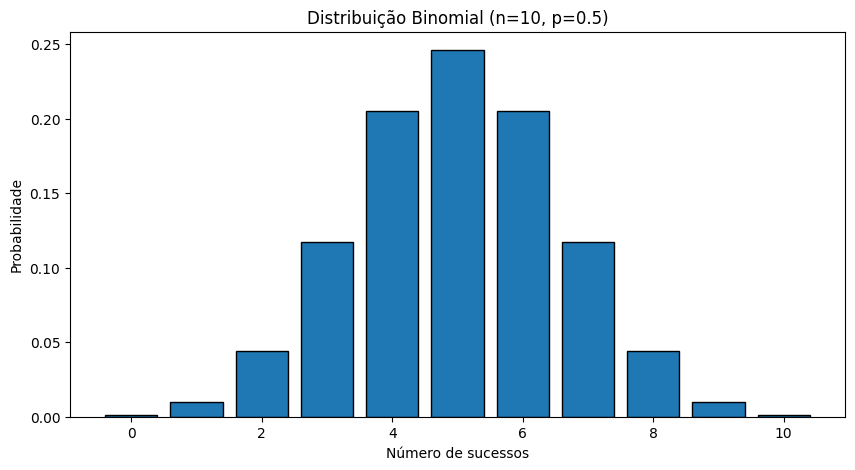

In [28]:
# CÉLULA 8 — GRÁFICO DA DISTRIBUIÇÃO BINOMIAL

plt.figure(figsize=(10, 5))
plt.bar(valores_binom, prob_binom, edgecolor="black")

plt.title("Distribuição Binomial (n=10, p=0.5)")
plt.xlabel("Número de sucessos")
plt.ylabel("Probabilidade")
plt.show()

> **Interpretação:**  
> A distribuição binomial mostra a probabilidade de obter diferentes quantidades de sucesso em 10 tentativas. Como a chance de sucesso é 0.5, a distribuição fica aproximadamente simétrica, com maior concentração em torno dos valores centrais.


### 8.1 Simulação da Binomial


In [29]:
# CÉLULA 9 — SIMULAÇÃO DE UMA BINOMIAL

# Simula 10.000 experimentos, cada um com 10 tentativas e probabilidade de sucesso 0.5
amostras_binom = np.random.binomial(n=10, p=0.5, size=10000)

pd.Series(amostras_binom).head()

,0
0,5
1,5
2,5
3,5
4,3


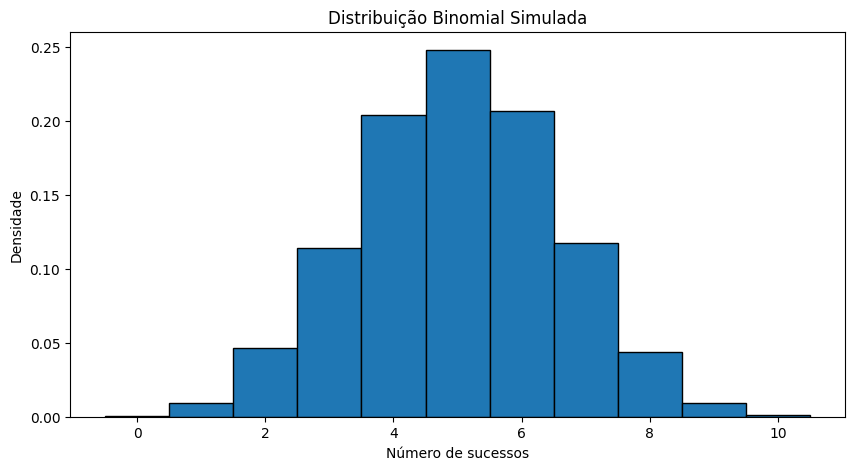

In [30]:
# CÉLULA 10 — HISTOGRAMA DA BINOMIAL SIMULADA

plt.figure(figsize=(10, 5))
plt.hist(amostras_binom, bins=np.arange(-0.5, 11.5, 1), edgecolor="black", density=True)

plt.title("Distribuição Binomial Simulada")
plt.xlabel("Número de sucessos")
plt.ylabel("Densidade")
plt.show()

> **Interpretação:**  
> A distribuição simulada apresenta formato muito próximo ao da distribuição binomial teórica, mostrando que a simulação reproduz bem o comportamento esperado do processo aleatório.


## 9. Distribuição de Poisson

A distribuição de Poisson é usada para modelar contagens de eventos em um intervalo fixo de tempo, espaço ou volume, quando esses eventos ocorrem de forma independente.

Exemplos:

- número de chamadas por minuto em uma central;
- quantidade de defeitos por metro de tecido;
- número de acessos por segundo em uma API.


In [31]:
# CÉLULA 11 — DISTRIBUIÇÃO DE POISSON

# lambda representa a taxa média de ocorrência
lam = 4

valores_poisson = np.arange(0, 15)
prob_poisson = stats.poisson.pmf(valores_poisson, mu=lam)

df_poisson = pd.DataFrame({
    "eventos": valores_poisson,
    "probabilidade": prob_poisson
})

df_poisson

,eventos,probabilidade
0,0,0.018316
1,1,0.073263
2,2,0.146525
3,3,0.195367
4,4,0.195367
5,5,0.156293
6,6,0.104196
7,7,0.059540
8,8,0.029770
9,9,0.013231


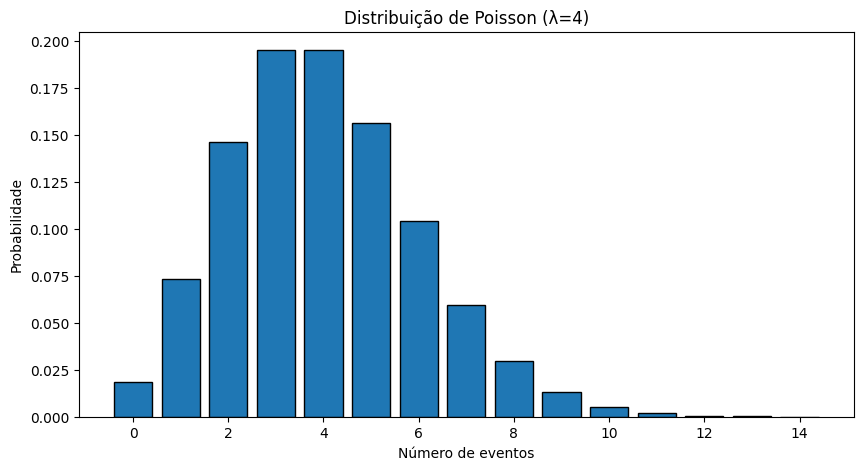

In [32]:
# CÉLULA 12 — GRÁFICO DA DISTRIBUIÇÃO DE POISSON

plt.figure(figsize=(10, 5))
plt.bar(valores_poisson, prob_poisson, edgecolor="black")

plt.title("Distribuição de Poisson (λ=4)")
plt.xlabel("Número de eventos")
plt.ylabel("Probabilidade")
plt.show()

> **Interpretação:**  
> A distribuição de Poisson concentra maior probabilidade em torno da taxa média de ocorrência. Nesse exemplo, valores próximos de 4 eventos são os mais prováveis, enquanto contagens muito baixas ou muito altas se tornam menos frequentes.


## 10. Distribuição Normal

A distribuição normal é uma das mais importantes da estatística. Ela aparece com frequência em fenômenos naturais e em diversas aproximações teóricas.

Suas principais características são:

- formato simétrico;
- concentração em torno da média;
- caudas que diminuem gradualmente;
- totalmente definida por média e desvio padrão.

Se $X \sim N(\mu, \sigma)$, então:

- $\mu$ representa o centro da distribuição;
- $\sigma$ representa a dispersão.

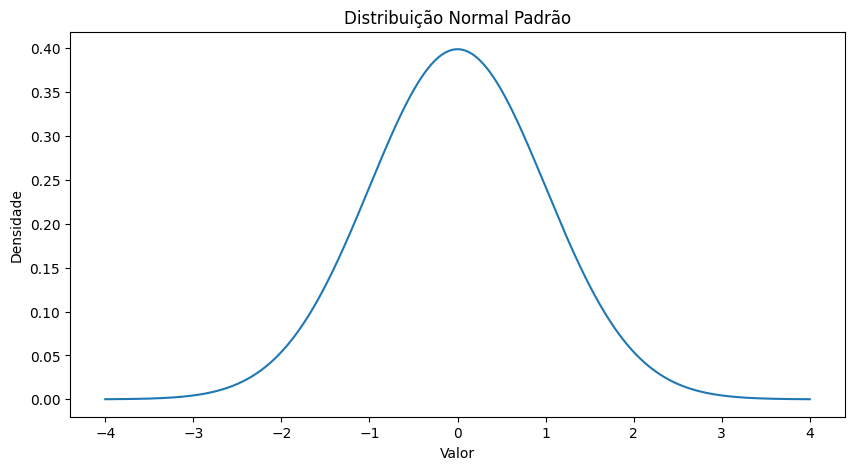

In [33]:
# CÉLULA 13 — CURVA DA DISTRIBUIÇÃO NORMAL PADRÃO

# Cria uma grade de valores no eixo x
x = np.linspace(-4, 4, 1000)

# pdf = probability density function
# Retorna a densidade teórica da normal padrão
y = stats.norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(10, 5))
plt.plot(x, y)

plt.title("Distribuição Normal Padrão")
plt.xlabel("Valor")
plt.ylabel("Densidade")
plt.show()

> **Interpretação:**  
> A curva normal apresenta formato simétrico em torno da média zero, indicando que valores centrais possuem maior densidade e que a probabilidade de observar valores extremos diminui à medida que nos afastamos do centro.


### 10.1 Efeito da média e do desvio padrão


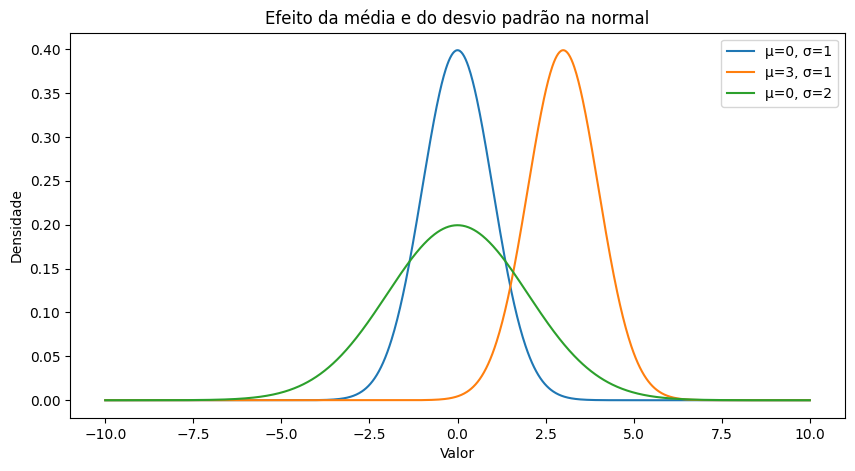

In [34]:
# CÉLULA 14 — EFEITO DA MÉDIA E DO DESVIO PADRÃO

x = np.linspace(-10, 10, 1000)

y1 = stats.norm.pdf(x, loc=0, scale=1)
y2 = stats.norm.pdf(x, loc=3, scale=1)
y3 = stats.norm.pdf(x, loc=0, scale=2)

plt.figure(figsize=(10, 5))
plt.plot(x, y1, label="μ=0, σ=1")
plt.plot(x, y2, label="μ=3, σ=1")
plt.plot(x, y3, label="μ=0, σ=2")

plt.title("Efeito da média e do desvio padrão na normal")
plt.xlabel("Valor")
plt.ylabel("Densidade")
plt.legend()
plt.show()

> **Interpretação:**  
> Alterar a média desloca a curva horizontalmente, enquanto aumentar o desvio padrão torna a distribuição mais espalhada e menos concentrada no centro. Isso ajuda a entender como os parâmetros controlam o comportamento da normal.


## 11. Simulação de uma variável contínua uniforme

Nem todo processo segue uma distribuição normal. Um caso simples é a distribuição uniforme contínua, em que todos os valores dentro de um intervalo possuem a mesma densidade.


In [35]:
# CÉLULA 15 — SIMULAÇÃO DE UMA UNIFORME CONTÍNUA

amostra_uniforme = np.random.uniform(0, 1, size=10000)

amostra_uniforme[:10]

array([0.50137193, 0.60538561, 0.61630765, 0.1703047 , 0.68641088,
       0.4523511 , 0.51738196, 0.0303166 , 0.76455663, 0.83542796])

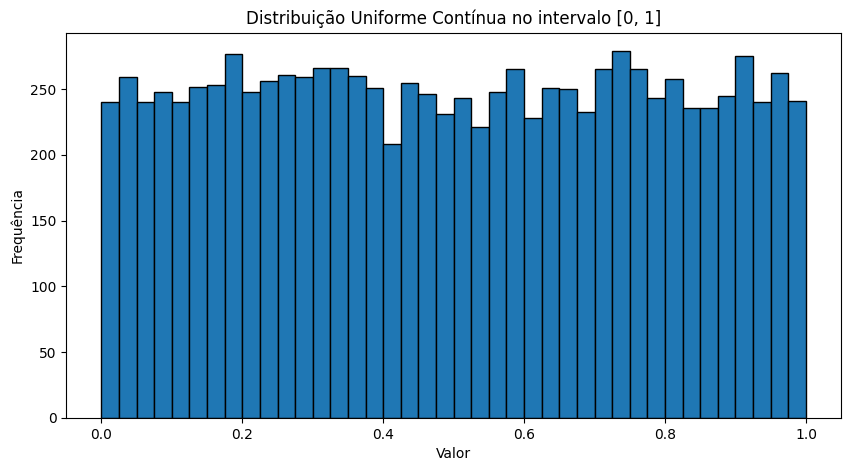

In [36]:
# CÉLULA 16 — HISTOGRAMA DA UNIFORME

plt.figure(figsize=(10, 5))
plt.hist(amostra_uniforme, bins=40, edgecolor="black")

plt.title("Distribuição Uniforme Contínua no intervalo [0, 1]")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

> **Interpretação:**  
> O histograma mostra distribuição aproximadamente plana ao longo do intervalo de 0 a 1, indicando que não há concentração preferencial em nenhuma região específica. Esse é o comportamento esperado da distribuição uniforme.


## 12. Simulação de Monte Carlo

A simulação de Monte Carlo usa repetição de experimentos aleatórios para aproximar probabilidades, médias ou quantidades difíceis de obter analiticamente.

Ela é muito útil quando:

- a solução exata é complexa;
- queremos validar um resultado teórico;
- precisamos estimar risco ou variabilidade.


In [37]:
# CÉLULA 17 — ESTIMANDO UMA PROBABILIDADE POR MONTE CARLO

# Gera 100.000 valores uniformes entre 0 e 1
simulacoes = np.random.rand(100000)

# Estima a probabilidade de o valor ser menor que 0.3
prob_monte_carlo = np.mean(simulacoes < 0.3)

print(f"Probabilidade teórica: 0.300")
print(f"Probabilidade estimada por Monte Carlo: {prob_monte_carlo:.3f}")

Probabilidade teórica: 0.300
Probabilidade estimada por Monte Carlo: 0.299


Nesse exemplo, sabemos teoricamente que a probabilidade é 0.3. A simulação serve para mostrar que, com muitas repetições, a estimativa empírica tende a se aproximar do valor real.


## 13. Lei dos Grandes Números

A Lei dos Grandes Números afirma, de forma simplificada, que:

> conforme o número de observações aumenta, a média amostral tende a se aproximar do valor esperado.

Esse resultado é central em estatística, porque explica por que médias calculadas com mais dados costumam ser mais estáveis.


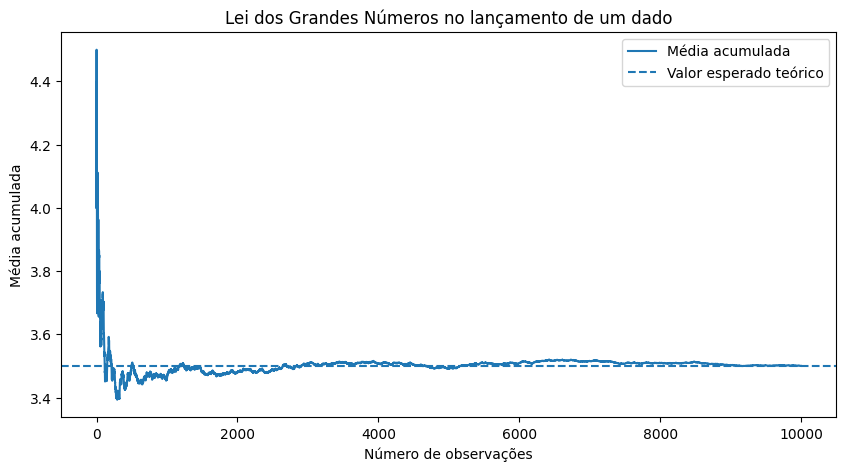

In [38]:
# CÉLULA 18 — MÉDIA ACUMULADA DOS LANÇAMENTOS DO DADO

# Calcula a média acumulada dos lançamentos
medias_acumuladas = np.cumsum(resultados_dado) / np.arange(1, len(resultados_dado) + 1)

plt.figure(figsize=(10, 5))
plt.plot(medias_acumuladas, label="Média acumulada")
plt.axhline(3.5, linestyle="--", label="Valor esperado teórico")

plt.title("Lei dos Grandes Números no lançamento de um dado")
plt.xlabel("Número de observações")
plt.ylabel("Média acumulada")
plt.legend()
plt.show()

> **Interpretação:**  
> A média acumulada oscila bastante no início, mas tende a se estabilizar com o aumento do número de observações. Isso ilustra a Lei dos Grandes Números: quanto maior a amostra, mais próxima a média observada fica do valor esperado teórico.


## 14. Distribuição amostral em diferentes tamanhos

Uma forma útil de conectar probabilidade com inferência é observar como estatísticas amostrais variam conforme o tamanho da amostra muda.


In [39]:
# CÉLULA 19 — EFEITO DO TAMANHO DA AMOSTRA NA MÉDIA

tamanhos = [5, 20, 100]
resultados_medias = {}

for n in tamanhos:
    medias = []
    for _ in range(3000):
        amostra_temp = np.random.randint(1, 7, size=n)
        medias.append(np.mean(amostra_temp))
    resultados_medias[n] = medias

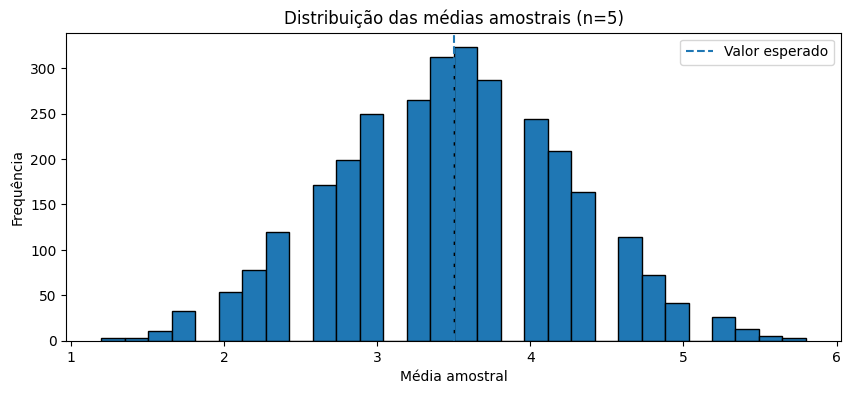

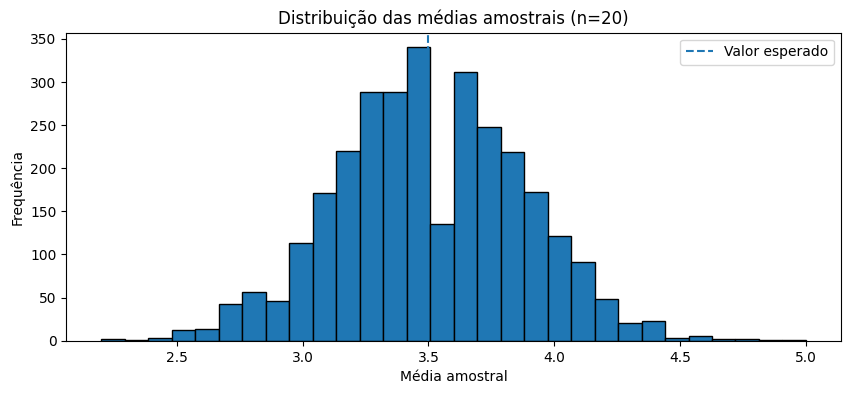

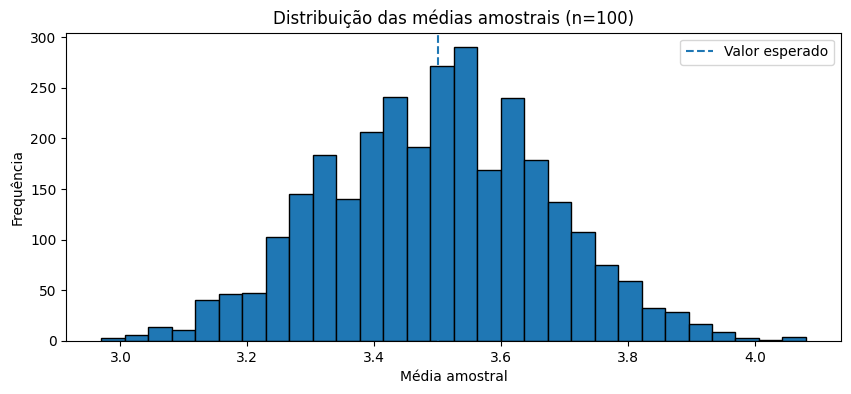

In [40]:
# CÉLULA 20 — HISTOGRAMAS DAS MÉDIAS PARA DIFERENTES TAMANHOS AMOSTRAIS

for n in tamanhos:
    plt.figure(figsize=(10, 4))
    plt.hist(resultados_medias[n], bins=30, edgecolor="black")
    plt.axvline(3.5, linestyle="--", label="Valor esperado")
    plt.title(f"Distribuição das médias amostrais (n={n})")
    plt.xlabel("Média amostral")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

> **Interpretação:**  
> À medida que o tamanho da amostra aumenta, a distribuição das médias amostrais fica mais concentrada em torno do valor esperado. Isso mostra que amostras maiores produzem estimativas mais estáveis e menos variáveis.


## 15. Resumo conceitual

Ao longo deste capítulo, vimos que:

- a probabilidade formaliza a incerteza;
- distribuições descrevem o comportamento de variáveis aleatórias;
- simulações ajudam a validar conceitos teóricos;
- a média empírica tende a estabilizar com mais observações;
- o tamanho da amostra influencia diretamente a variabilidade das estimativas.

Esses conceitos formam a base para temas mais avançados, como inferência estatística, modelagem probabilística e aprendizado de máquina.


## 16. Referências bibliográficas

- Blitzstein, J. K.; Hwang, J. (2019). *Introduction to Probability*. Chapman and Hall/CRC.  
- Grinstead, C. M.; Snell, J. L. (1997). *Introduction to Probability*. American Mathematical Society.  
- Ross, S. M. (2014). *Introduction to Probability Models*. Academic Press.  
- Wasserman, L. (2004). *All of Statistics*. Springer.
